# Annihilation profile Heatmaps

In [2]:
import sys
sys.path.insert(0, r'C:\Users\jeanv\OneDrive - Delft University of Technology\Uitwisseling - TUDelft\Courses\MEP\Programming')

# Packages
import numpy as np
import matplotlib.pyplot as plt

# Files importation
from pals_analysis import config
from pals_analysis.physics.implantation import makhov_profile
from pals_analysis.physics.annihilation import calculate_annihilation_profile
from pals_analysis.analysis.thickness_solver import numerical_S_curve
from pals_analysis.visualization.plots import create_heatmap
from pals_analysis.visualization import setup_plot_style

# Define energies we are probing
energies = np.linspace(5, 25, 100)  # in keV
energies_line = np.array([3,8,10,20])

In [3]:
def thickness_layer(layers):
    depth = 0
    i = 0
    for i in range(len(layers)):
        depth += layers[i]['thickness']
        i += 1
    
    return depth

# We define the layers we will be using.
# We also configure the grid and which one to use based its depth
# The function thickness_layer calculates the depth of each created layer.

layers_steel = [
    {'thickness': 1000, 'density': 8.00, 'L_diff': 150, 'S_param': 0.515}  # Steel (Substrate)
    ]

z_pts = 2000 # fineness of the grid

z_grid_steel = np.linspace(0, thickness_layer(layers_steel), z_pts)

9.999468469799874
9.99953174391035
9.999585488913267
9.999631419675062
9.999670895492761
9.99970500292279
9.9997346173282
9.999760449091532
9.999783078652682
9.99980298331622
9.999820557936626
9.999836131007331
9.999849977268957
9.999862327659871
9.999873377221693
9.99988329141979
9.999892211226713
9.99990025723385
9.999907532994875
9.99991412775768
9.999920118702747
9.999925572761487
9.99993054799723
9.999935094286199
9.999939252391899
9.999943049036707
9.99994648258455
9.999949488748209
9.999951867907134
9.9999531455182
9.99995232623214
9.999947493403155
9.999935202141687
9.999909619169529
9.999861378481965
9.999776148072215
9.99963293717958
9.999402211096022
9.999043915815726
9.998505542143157
9.997720373910376
9.996606065305645
9.995063677871345
9.992977280467308
9.990214178944422
9.986625800793034
9.982049218086917
9.976309253600752
9.969221083088843
9.960593223314541
9.95023078133254
9.937938835581175
9.92352582260267
9.906806813226689
9.887606577111177
9.865762352866454
9.841126

(<Figure size 1200x800 with 2 Axes>,
 <Axes: title={'center': 'Annihilation Profiles for Steel'}, xlabel='Energy (keV)', ylabel='Depth (nm)'>)

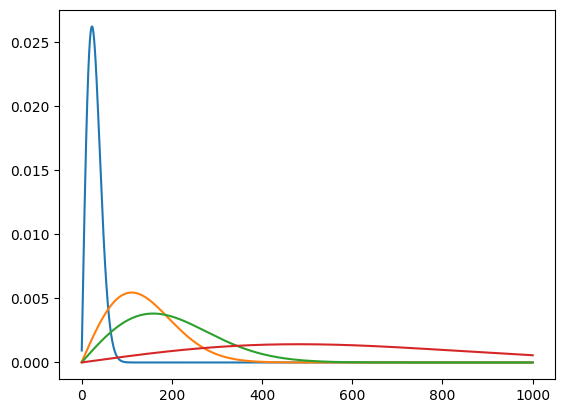

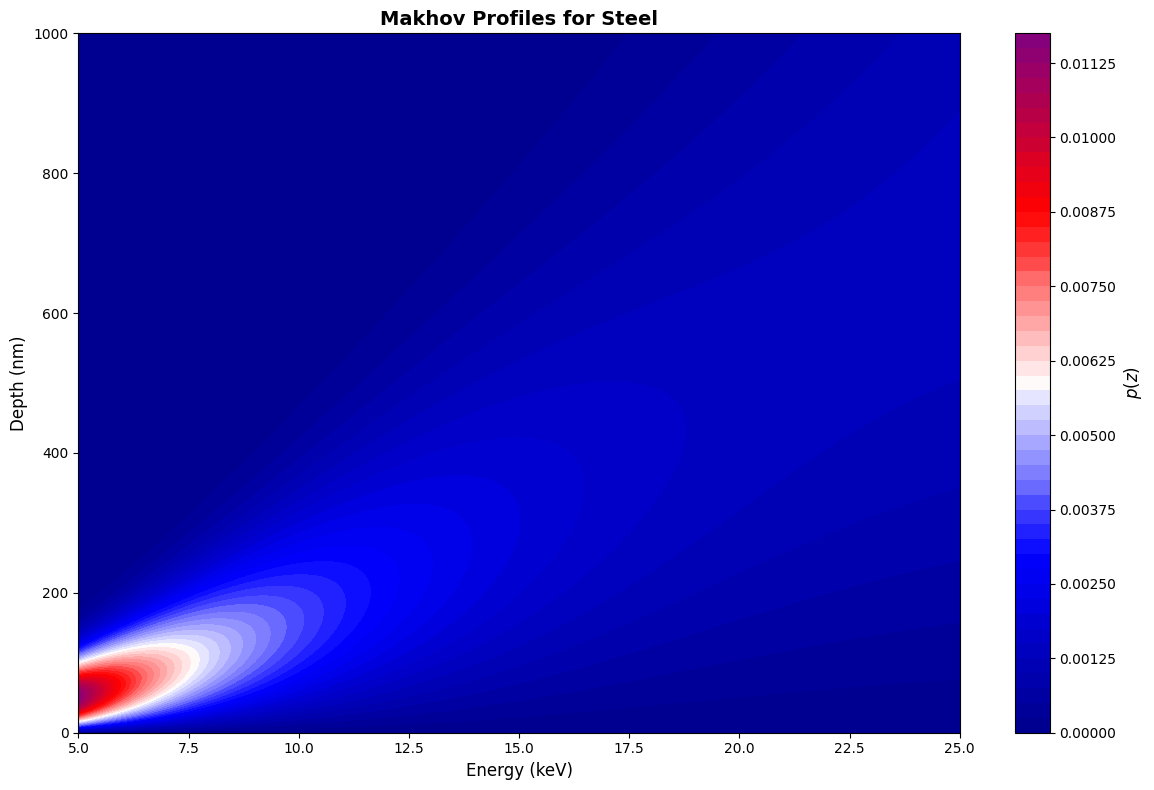

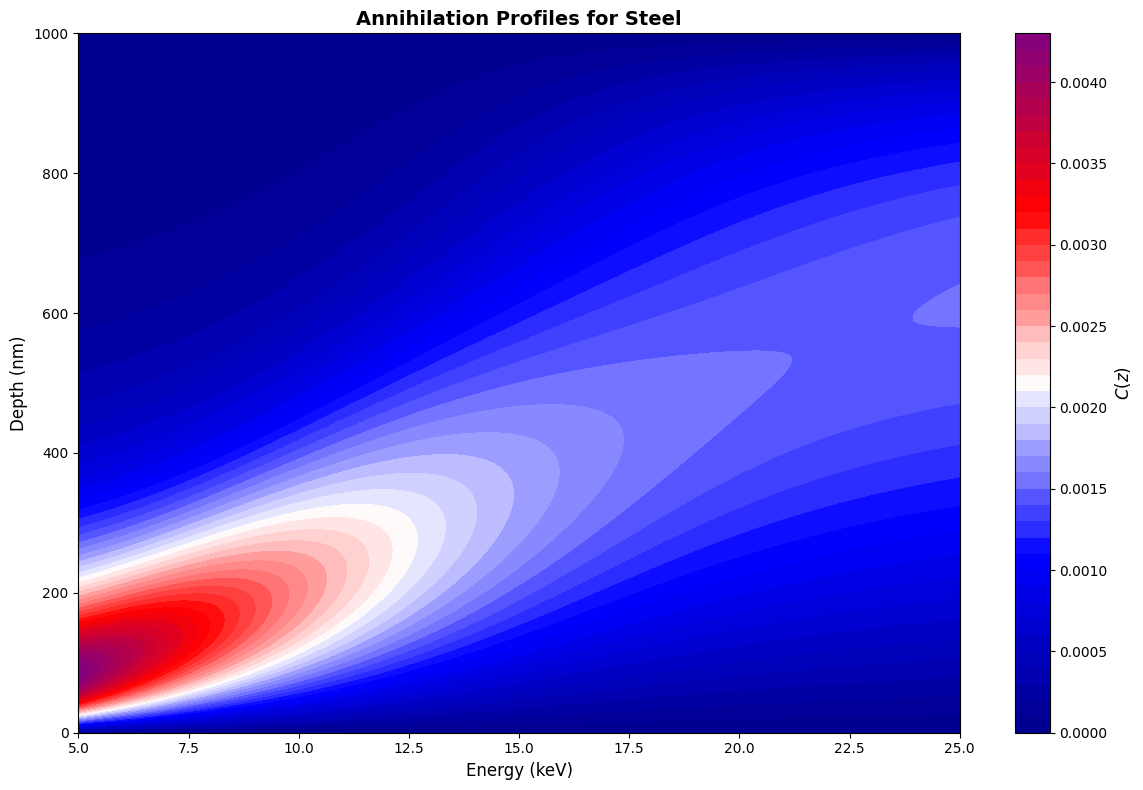

In [5]:
matrix_sharp_steel = []
matrix_sharp_steel_diffused = []
for E in energies:
# Run Sharp (Standard)
    p_s = makhov_profile(z_grid_steel, E, layers_steel, model='layered')
    c_s = calculate_annihilation_profile(z_grid_steel, p_s, layers_steel, model="layered")
    matrix_sharp_steel.append(p_s)
    matrix_sharp_steel_diffused.append(c_s)

matrix_sharp_steel_line = []
plt.figure()
for E in energies_line:
# Run Sharp (Standard)
    p_s = makhov_profile(z_grid_steel, E, layers_steel, model='layered')
    plt.plot(z_grid_steel, p_s)
    matrix_sharp_steel_line.append(p_s)


matrix_sharp_steel = np.array(matrix_sharp_steel)
matrix_sharp_steel_diffused = np.array(matrix_sharp_steel_diffused)

create_heatmap(
        energies, z_grid_steel, matrix_sharp_steel,
        title="Makhov Profiles for Steel",
        save_as="heatmap_sharp.pdf",cbar_label=r'$p(z)$'
    )

create_heatmap(
        energies, z_grid_steel, matrix_sharp_steel_diffused,
        title="Annihilation Profiles for Steel",
        save_as="heatmap_sharp.pdf",cbar_label=r'$C(z)$'
    )
